In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import (
    OptimizerAgent,
    OptimizerAgentK2,
    OptimizerAgentK3,
    OptimizerAgentK4,
    OptimizerAgentKm,
)
from ant.centralised import P4

In [2]:
market_seed = 21234
graph_seed = 1
market_size = 40
cavement_div = 5
ks = [
#    1,
    2,
    3,
    4,
    5,
    6
]
graphs = {
    "Ladder": nx.circular_ladder_graph(int(market_size / 2)),
    "Scale-free": nx.barabasi_albert_graph(market_size, 1, seed=graph_seed),
    # "Small-World": nx.watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=graph_seed),
    "Caveman": nx.connected_caveman_graph(int(market_size / cavement_div), cavement_div)
}

markets = {}

for graph_type in graphs.keys():
    markets[graph_type] = []
    for optimizer_k in ks:
        _market = Market(market_size, graph=graphs[graph_type], seed=market_seed, agent_type=OptimizerAgent, k=optimizer_k)
        markets[graph_type].append({
            "agent_strategy": "Optimizer",
            "k": optimizer_k,
            "graph_type": graph_type,
            "market": _market,
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": np.mean(np.array([agent.submarket.market_ratio for agent in _market.agents])),
            "max_market_ratio": np.max(np.array([agent.submarket.market_ratio for agent in _market.agents])),
        })
    # benchmark
    markets[graph_type].append({
            "agent_strategy": "Proportional",
            "k": None,
            "market": Market(market_size, graph=graphs[graph_type], seed=market_seed, agent_type=ProportionalAgent),
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        })
    markets[graph_type].append({
            "agent_strategy": "Optimal",
            "k": None,
            "market": Market(market_size, graph=graphs[graph_type], seed=market_seed, agent_type=OptimalAgent),
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        })


k=2
k=2
k=2


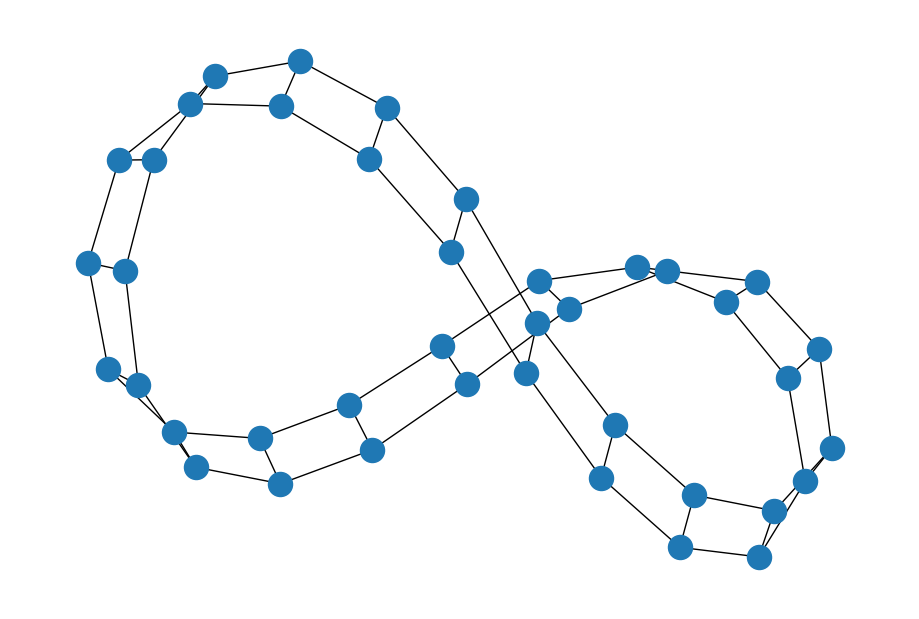

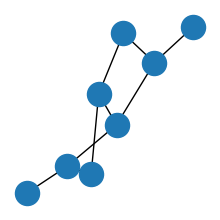

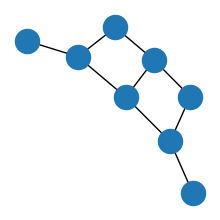

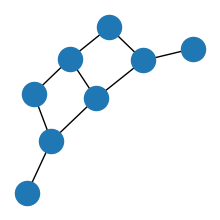

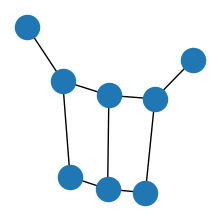

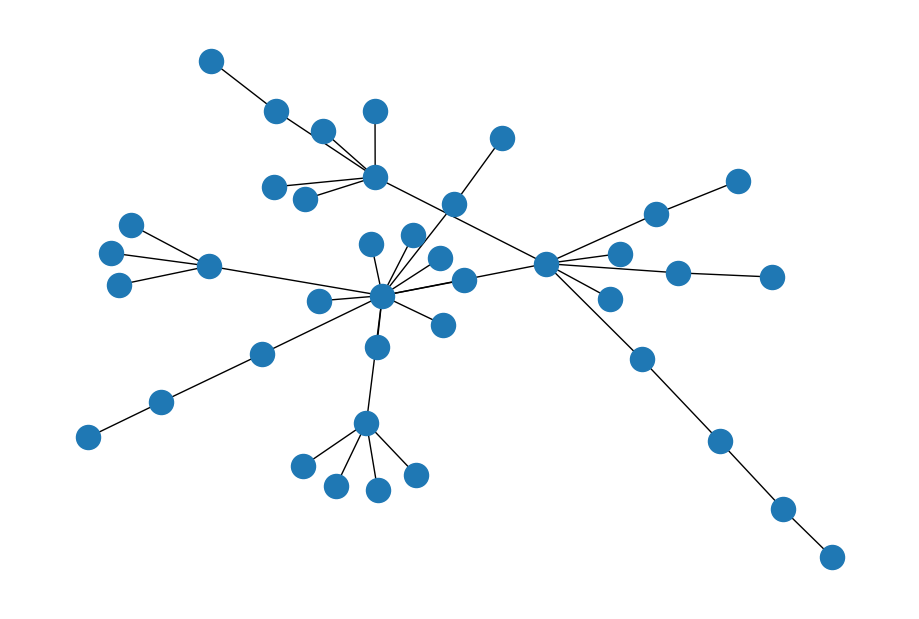

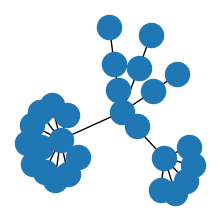

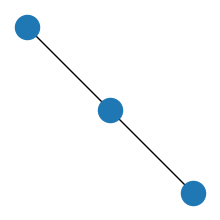

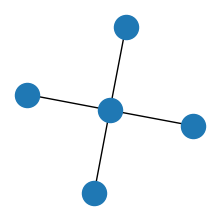

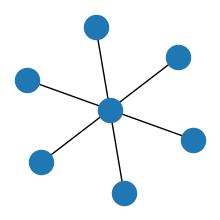

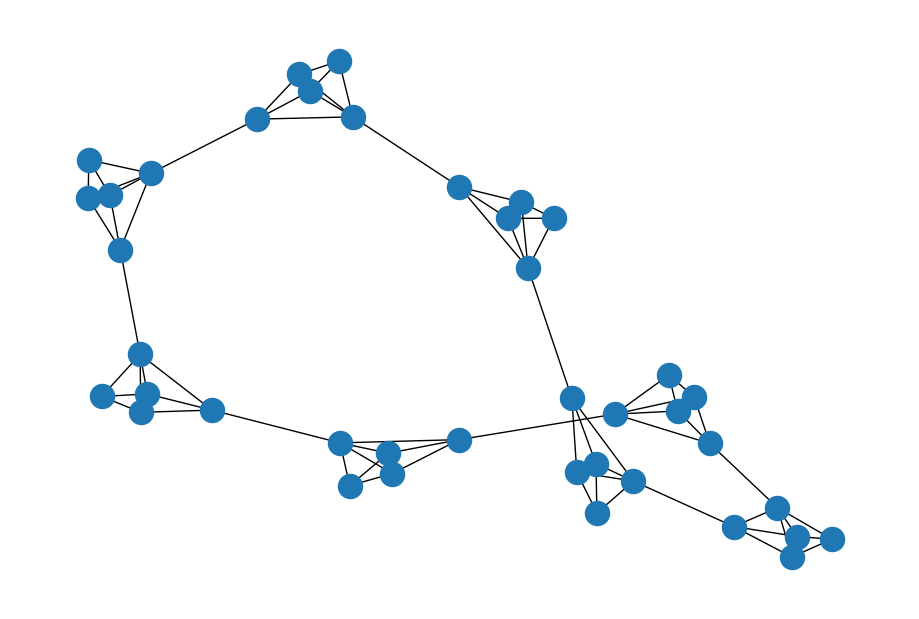

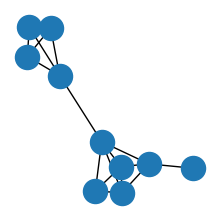

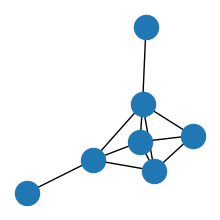

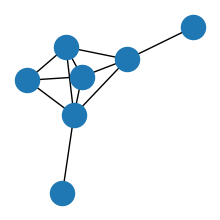

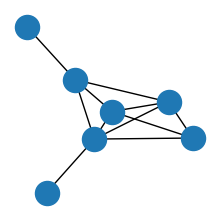

In [3]:
agent_indices = np.array([4, 12, 23, 37])

k_filter = [
    1,
#    2,
    3,
    4,
    5,
    6
]

for graph_type in markets.keys():
    plt.figure(figsize=(9, 6))
    nx.draw(graphs[graph_type])
    plt.draw()
    for market in markets[graph_type]:
        if market["agent_strategy"] == "Optimizer" and market["k"] not in k_filter:
            print(f"k={market['k']}")
            for agent in market["market"].agents[agent_indices]:
                plt.figure(figsize=(2, 2))
                nx.draw(agent.submarket.graph)
                plt.draw()

In [4]:
for graph_type in markets.keys():
    for entry in markets[graph_type]:
        entry["optimal_allocations"], entry["utility_vector"] = P4(entry["market"])
        entry["market"].set_market_equilibrium(entry["optimal_allocations"], entry["utility_vector"])